# STAGE 13 — ADAPTIVE RANKING GOOD DAY

Цель: проверить две причинные ranking-policy без переобучения forecasting-моделей и без нового threshold grid. **Ни одна policy автоматически не объявляется production winner.**

- `POLICY_FULL`: `(F_score + A_score + R_score) / 3`;
- `POLICY_SIMPLE`: `(F_score + R_score) / 2`;
- диагностически: SIMPLE без cooldown;
- единственный hard safety filter: `predicted_regret_5 <= 0.010`;
- `actual_regret_5` применяется только для ground truth/evaluation.

In [1]:
from pathlib import Path
import sys
import pandas as pd

ROOT = Path.cwd().resolve()
if not (ROOT / 'src').exists():
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from src.adaptive_ranking_good_day import run_adaptive_ranking
result = run_adaptive_ranking(ROOT, make_plots=True)
print('Input history:', len(result['full']), 'rows')
print('Locked test:', len(result['test']), 'rows')
print('Forecasting retraining: NO')

Input history: 2745 rows
Locked test: 1375 rows
Forecasting retraining: NO


## Online protocol

Компонентные percentile ranks и adaptive threshold используют только предыдущие 20 quote observations; строка T исключена. Если сигнал был менее 7 наблюдений назад, применяется 80-й percentile предыдущих scores; через 7–11 наблюдений — 65-й; через 12+ наблюдений или до первого сигнала — медиана. После сигнала следующие три quote observations блокируются. FULL и SIMPLE ведут независимое состояние.

In [2]:
display(result['results'])
print('\nMonthly table includes zero-signal months:')
display(result['monthly'].head(15))
print('\nLeakage audit:')
display(result['leakage'])

,corridor,policy,n_signals,signal_frequency,mean_signals_per_month,median_signals_per_month,months_with_zero_signals,share_months_with_1plus,share_months_with_2plus,max_gap_quote_observations,mean_gap_quote_observations,hit_rate,random_hit_rate,uplift,mean_actual_regret_signal
0,AMD_RUB,POLICY_FULL,33,0.120000,2.357143,2.0,1,0.928571,0.785714,20,7.906250,0.090909,0.095152,0.955414,0.013233
1,AMD_RUB,POLICY_SIMPLE,37,0.134545,2.642857,3.0,1,0.928571,0.785714,27,7.083333,0.162162,0.094108,1.723148,0.011301
2,AMD_RUB,POLICY_SIMPLE_NO_COOLDOWN,88,0.320000,6.285714,7.0,1,0.928571,0.857143,25,2.931034,0.125000,0.092659,1.349031,0.012193
3,KGS_RUB,POLICY_FULL,35,0.127273,2.500000,3.0,0,1.000000,0.785714,17,7.882353,0.114286,0.095714,1.194030,0.012590
4,KGS_RUB,POLICY_SIMPLE,38,0.138182,2.714286,3.0,1,0.928571,0.928571,18,7.000000,0.157895,0.093474,1.689189,0.011171
5,KGS_RUB,POLICY_SIMPLE_NO_COOLDOWN,79,0.287273,5.642857,7.0,0,1.000000,0.928571,18,3.512821,0.113924,0.094759,1.202244,0.013191
6,KZT_RUB,POLICY_FULL,35,0.127273,2.500000,2.5,0,1.000000,0.785714,18,7.970588,0.142857,0.107029,1.334757,0.011813
7,KZT_RUB,POLICY_SIMPLE,39,0.141818,2.785714,2.5,0,1.000000,0.857143,19,7.078947,0.153846,0.104769,1.468429,0.011404
8,KZT_RUB,POLICY_SIMPLE_NO_COOLDOWN,79,0.287273,5.642857,5.5,0,1.000000,0.857143,18,3.448718,0.126582,0.106557,1.187931,0.011775
9,TJS_RUB,POLICY_FULL,34,0.123636,2.428571,2.0,1,0.928571,0.785714,18,7.666667,0.205882,0.112824,1.824818,0.010528



Monthly table includes zero-signal months:


,corridor,month,n_signals,n_hits,hit_rate,policy
0,AMD_RUB,2025-07,0,0,NaN,POLICY_FULL
1,AMD_RUB,2025-08,4,0,0.000000,POLICY_FULL
2,AMD_RUB,2025-09,2,0,0.000000,POLICY_FULL
3,AMD_RUB,2025-10,2,0,0.000000,POLICY_FULL
4,AMD_RUB,2025-11,4,0,0.000000,POLICY_FULL
5,AMD_RUB,2025-12,2,1,0.500000,POLICY_FULL
6,AMD_RUB,2026-01,3,1,0.333333,POLICY_FULL
7,AMD_RUB,2026-02,2,0,0.000000,POLICY_FULL
8,AMD_RUB,2026-03,2,0,0.000000,POLICY_FULL
9,AMD_RUB,2026-04,3,0,0.000000,POLICY_FULL



Leakage audit:


,check,passed
0,component ranks use strictly previous 20 obser...,True
1,adaptive thresholds use strictly previous 20 s...,True
2,current observation excluded from rank and thr...,True
3,signals do not use actual_regret_5,True
4,validation precedes test and initializes onlin...,True
5,processing and state separated by corridor and...,True
6,forecasting models were not trained or tuned,True


## Как читать сравнение

Сравниваем FULL и SIMPLE по частоте, нулевым месяцам, максимальному gap, hit rate, uplift над random baseline того же размера и среднему фактическому regret сигналов. Это изолирует практический эффект `A_score`: помогает ли он качеству или, наоборот, создает лишние длинные паузы. Результаты являются locked-test диагностикой, но не автоматическим выбором production-policy.

## Графики сигналов внутри notebook

Для каждого валютного коридора ниже показаны: (1) сопоставимые панели `POLICY_FULL` и `POLICY_SIMPLE`, (2) отдельный чистый график сигналов `POLICY_SIMPLE`. Красные точки — даты, на которых online-policy выдала сигнал.

### AMD_RUB: FULL и SIMPLE

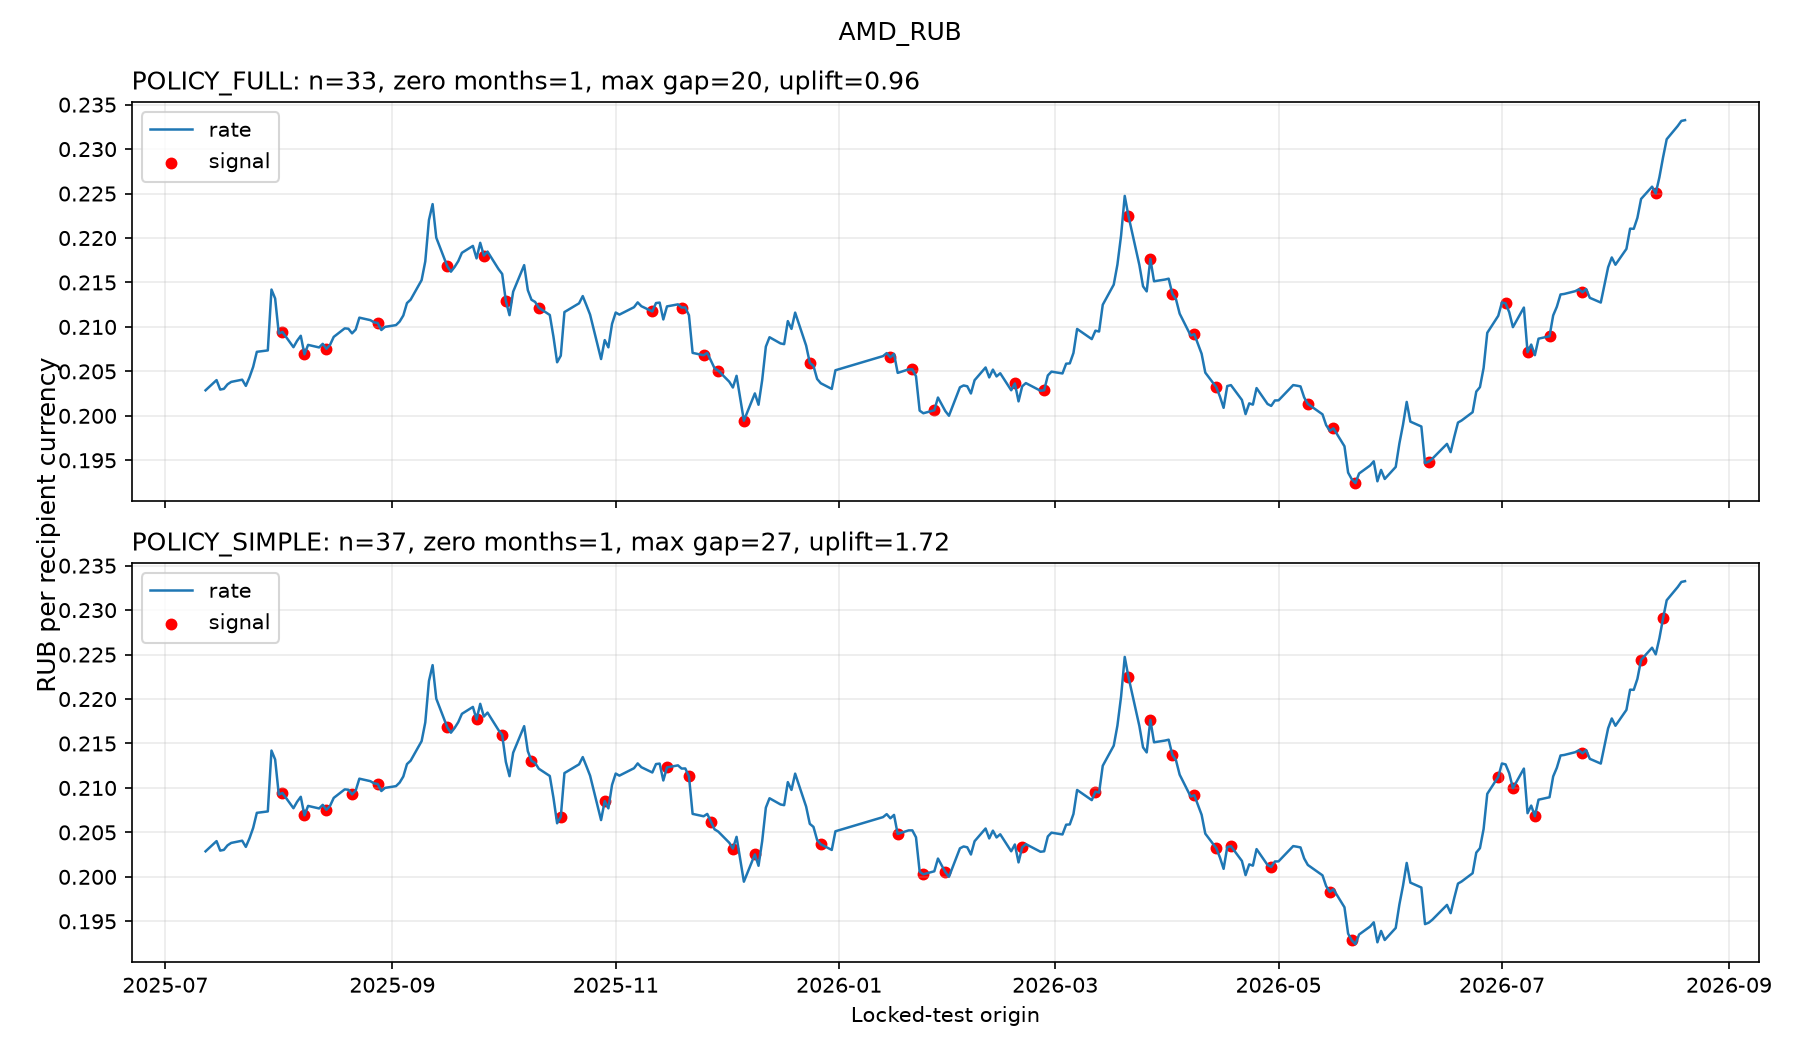

### AMD_RUB: отдельный POLICY_SIMPLE

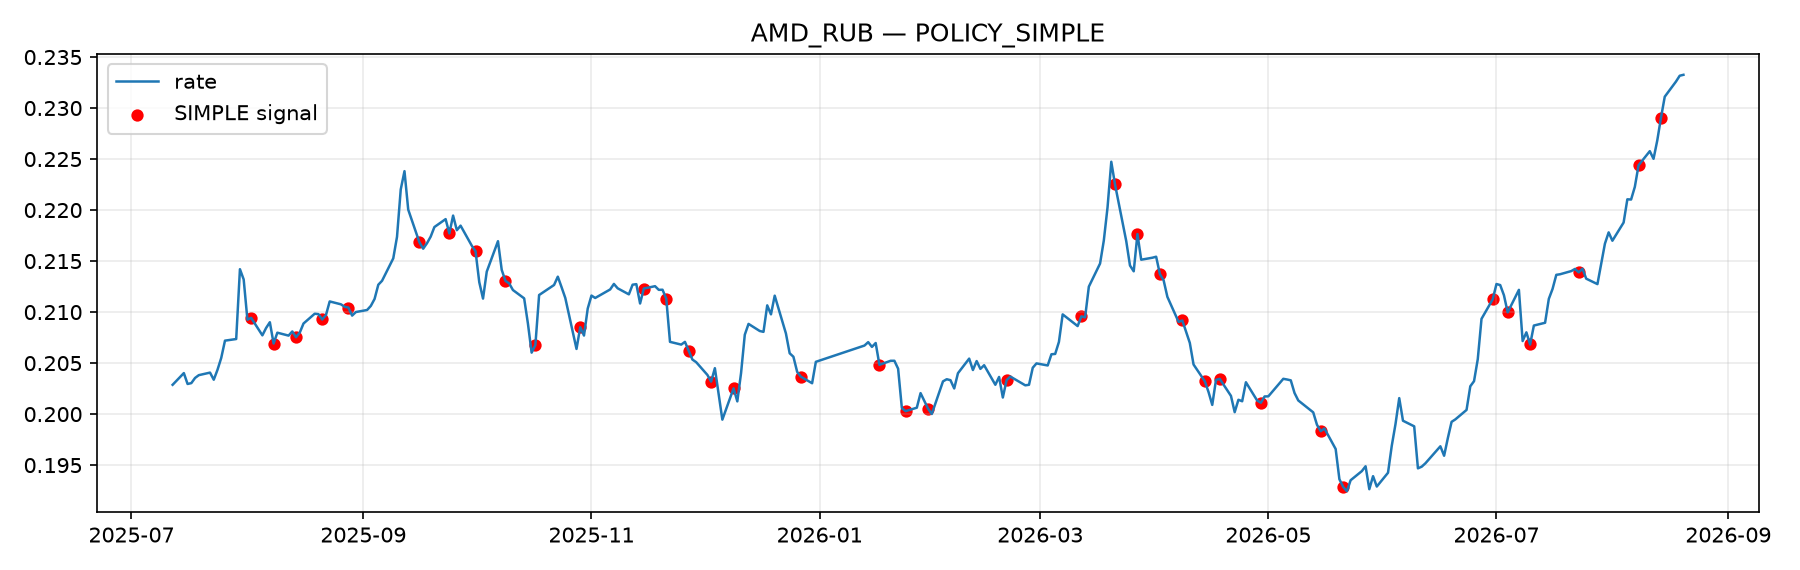

### KGS_RUB: FULL и SIMPLE

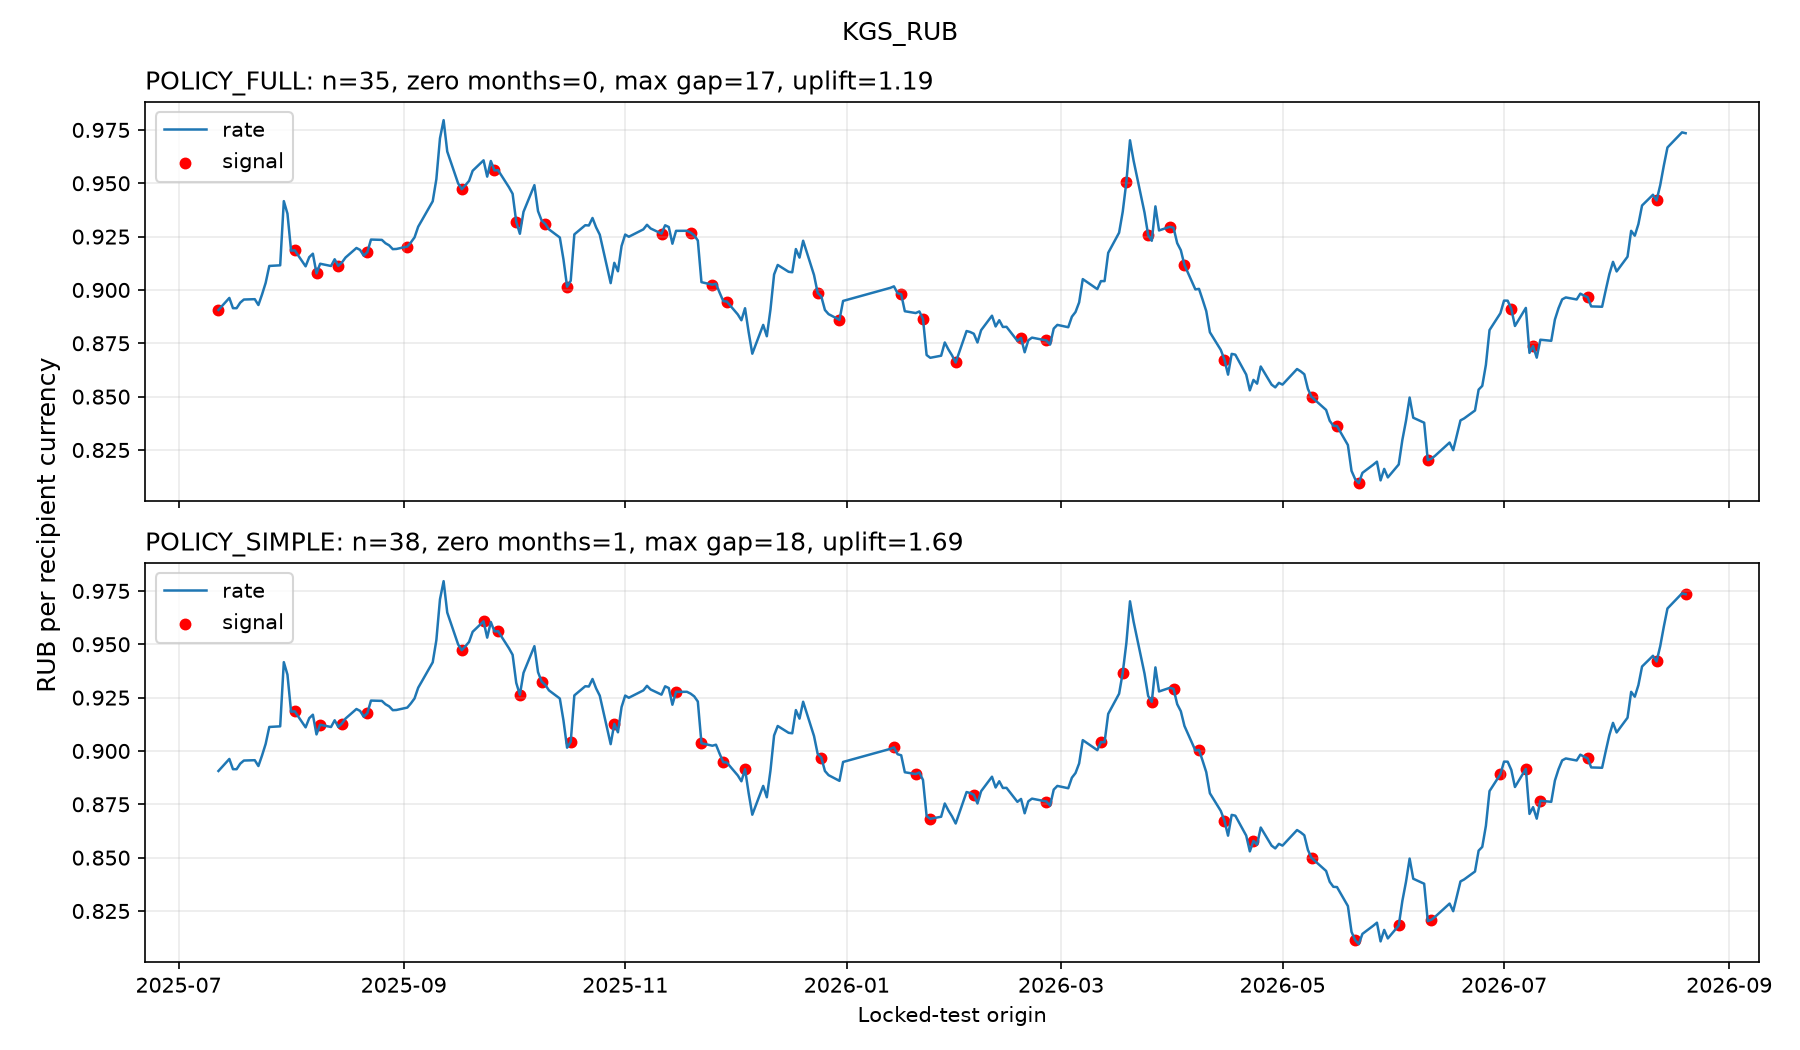

### KGS_RUB: отдельный POLICY_SIMPLE

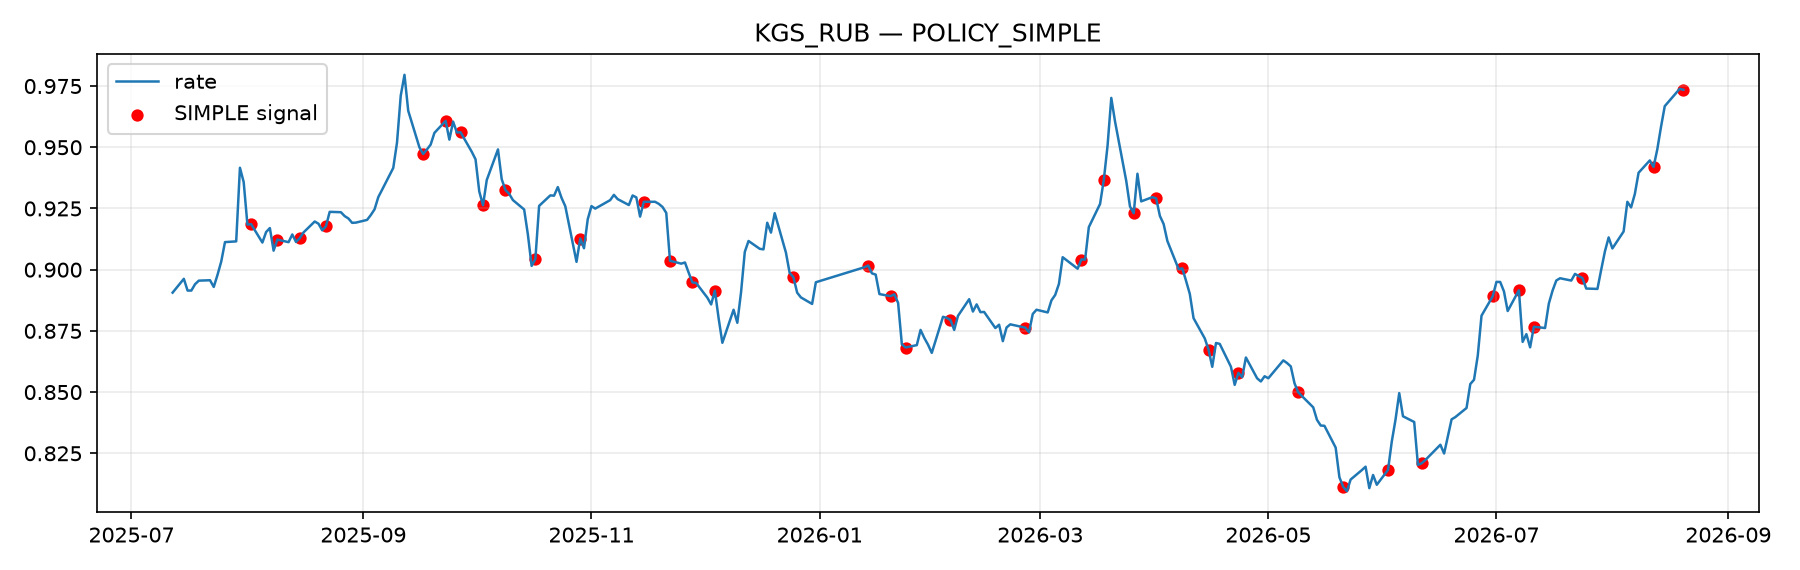

### KZT_RUB: FULL и SIMPLE

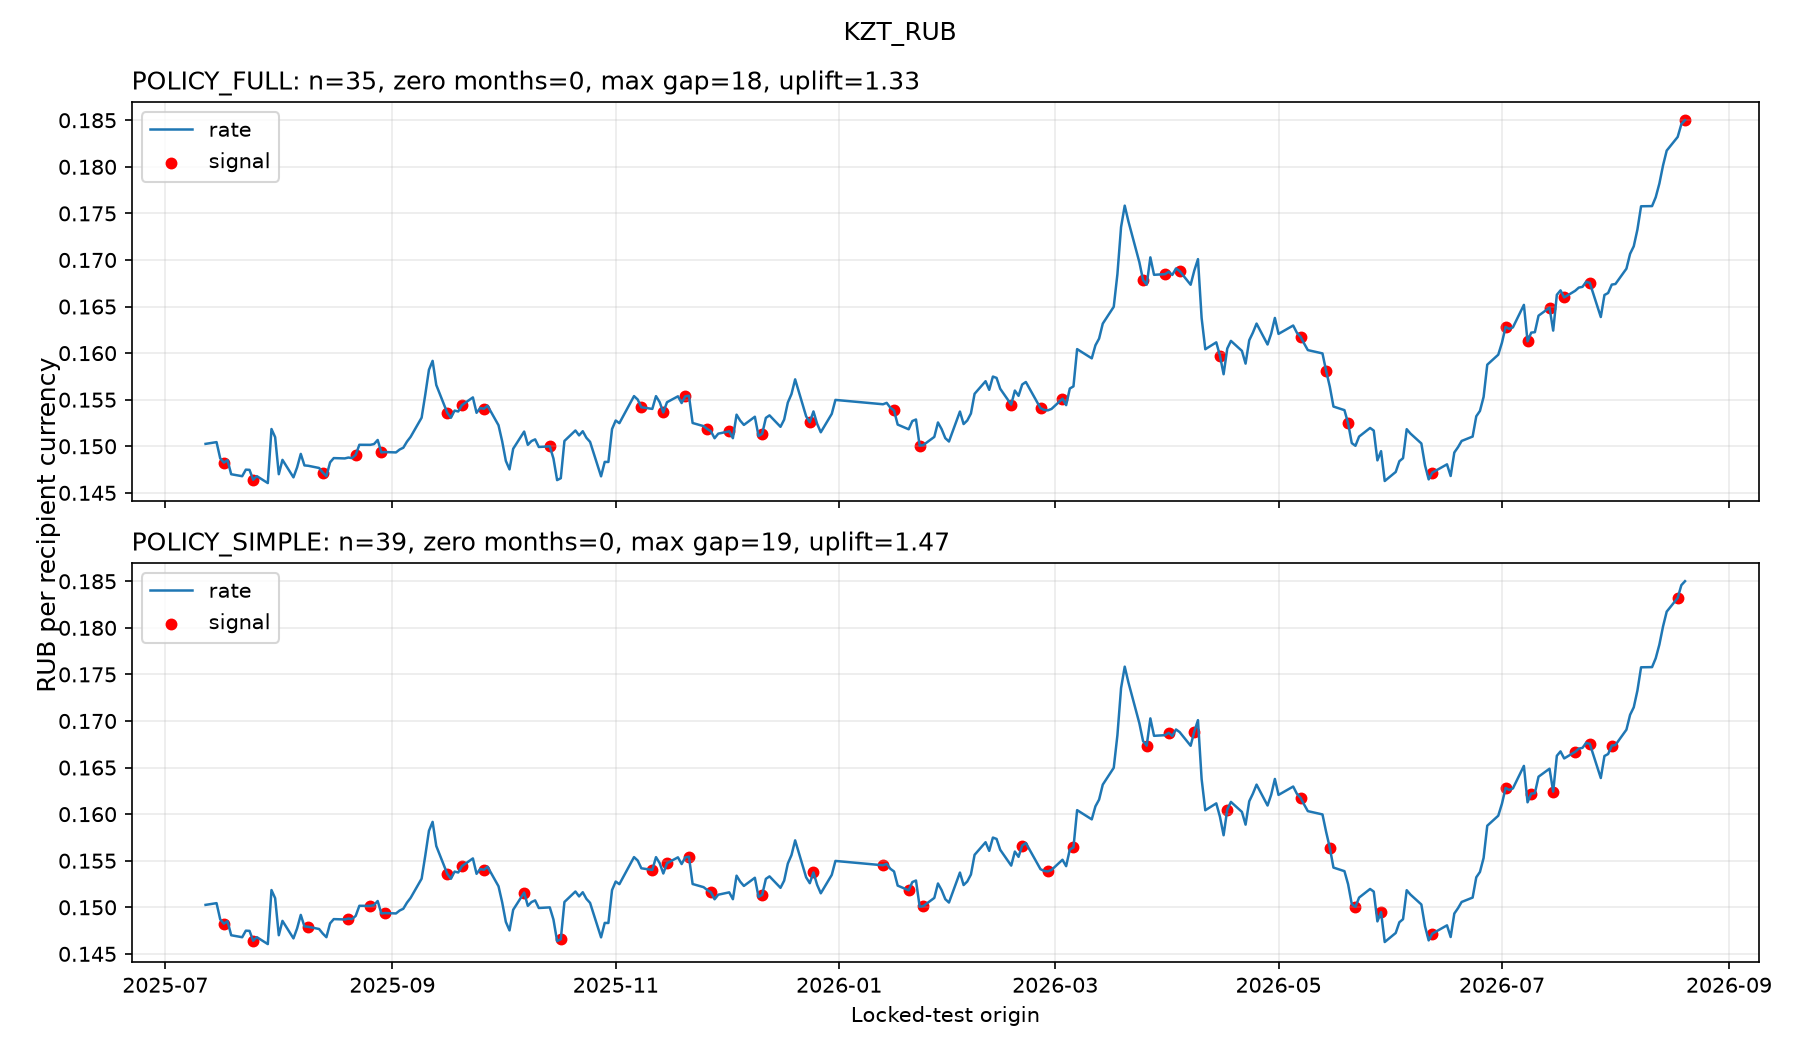

### KZT_RUB: отдельный POLICY_SIMPLE

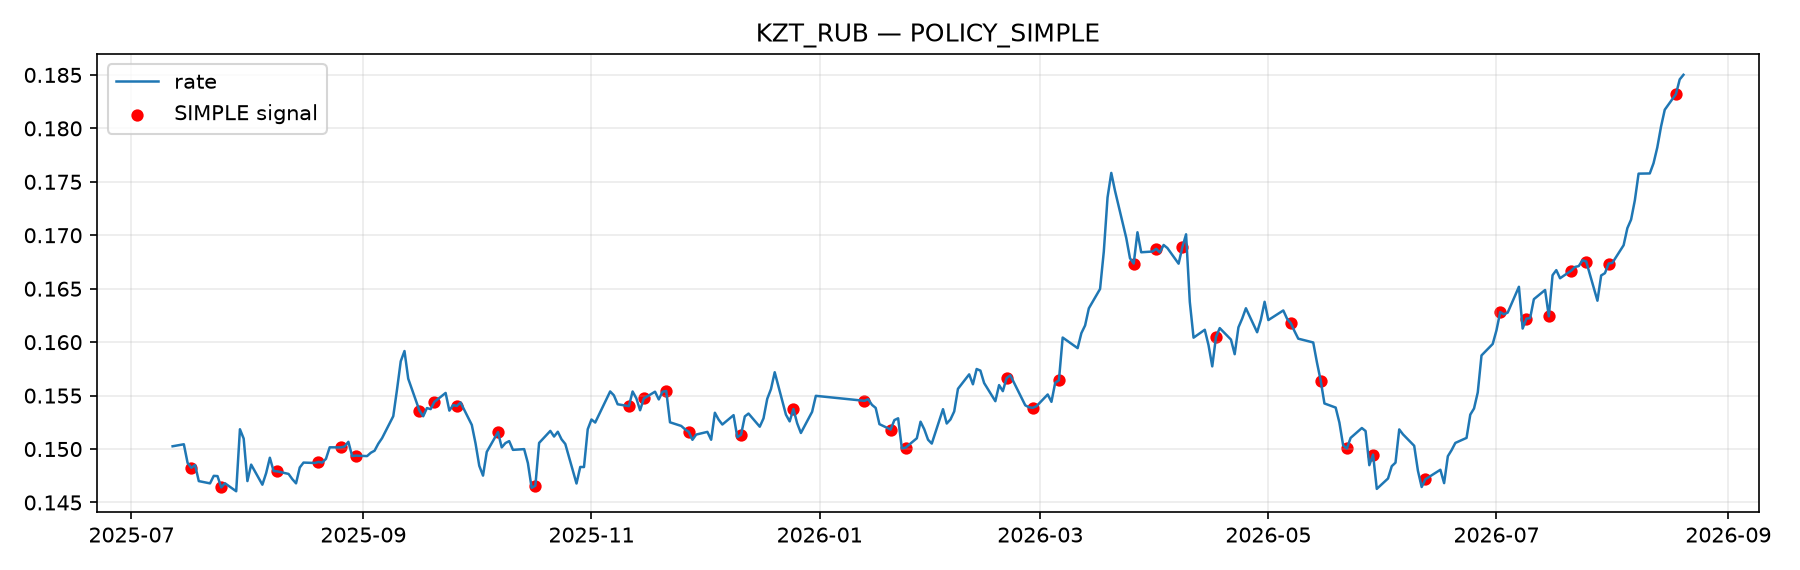

### TJS_RUB: FULL и SIMPLE

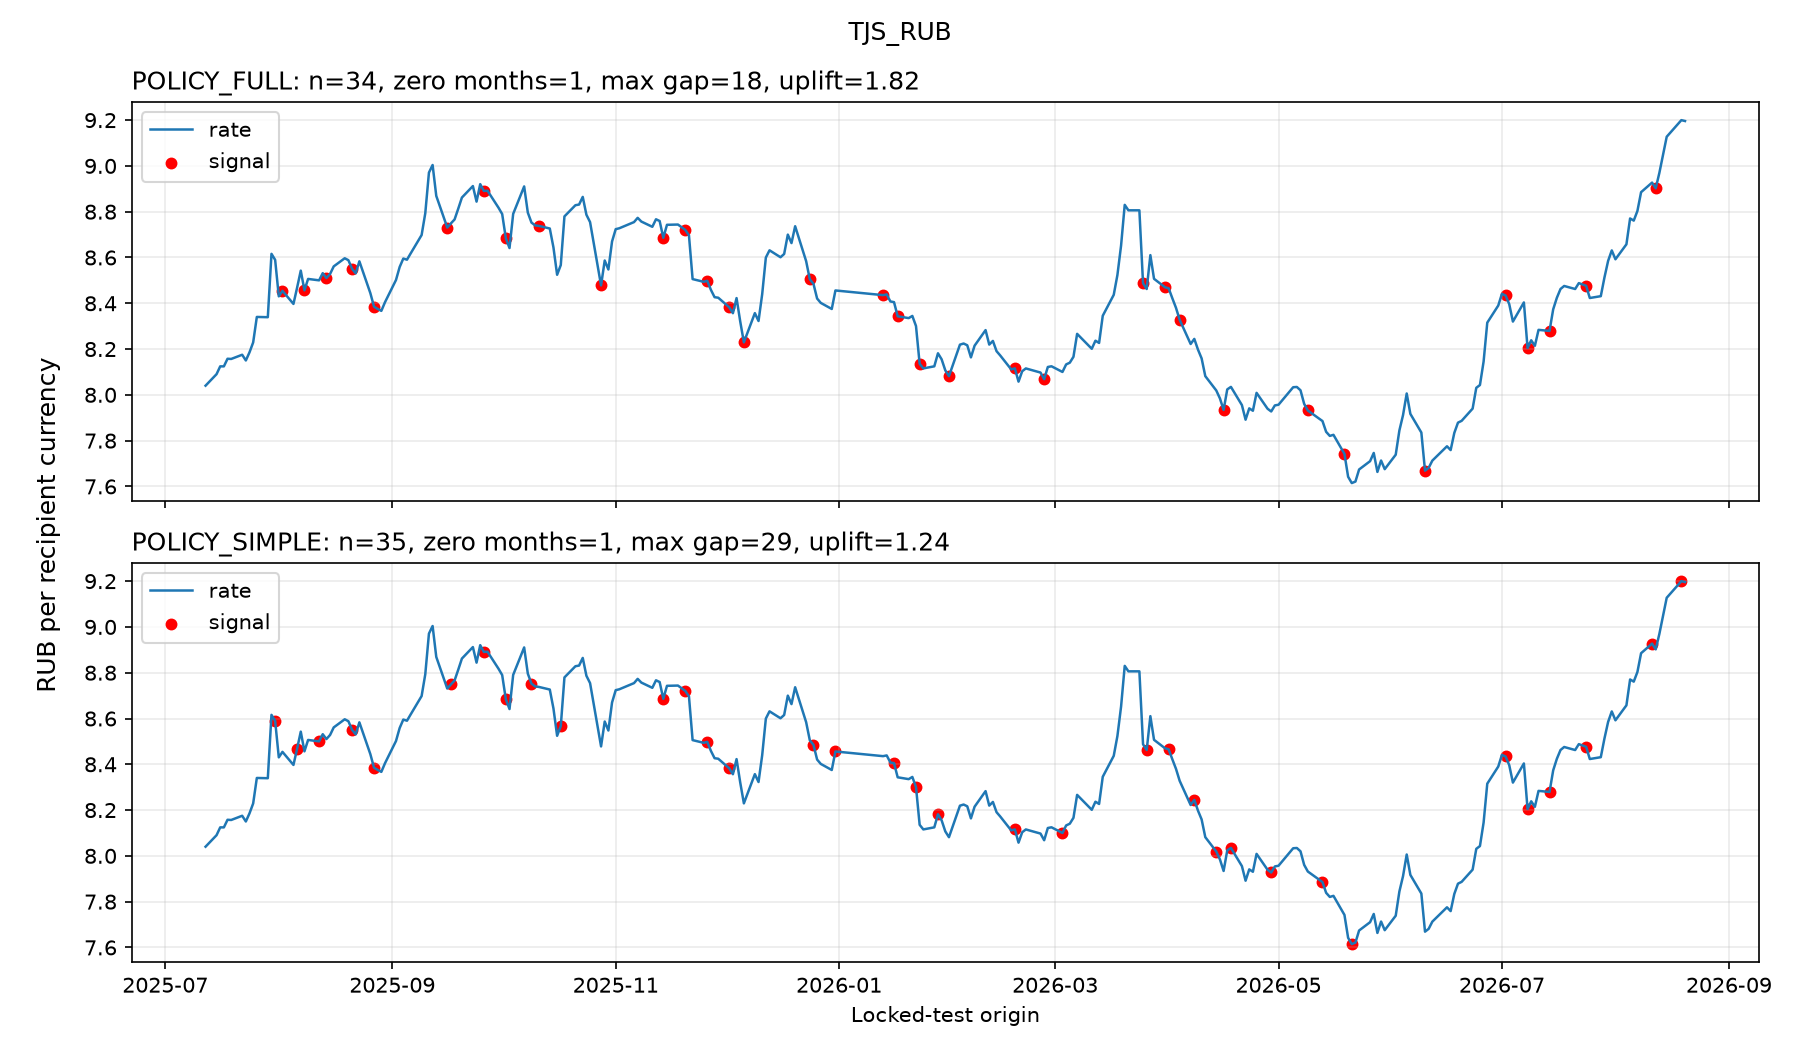

### TJS_RUB: отдельный POLICY_SIMPLE

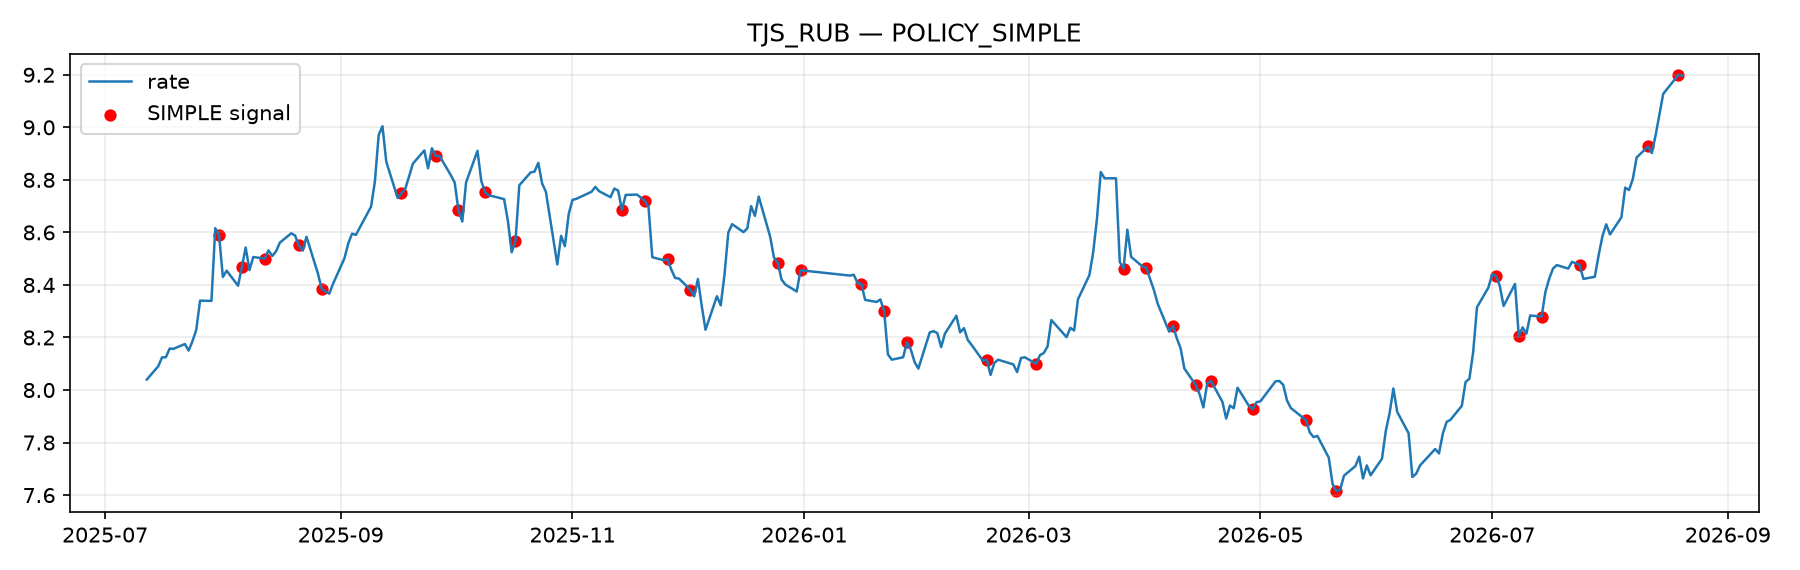

### UZS_RUB: FULL и SIMPLE

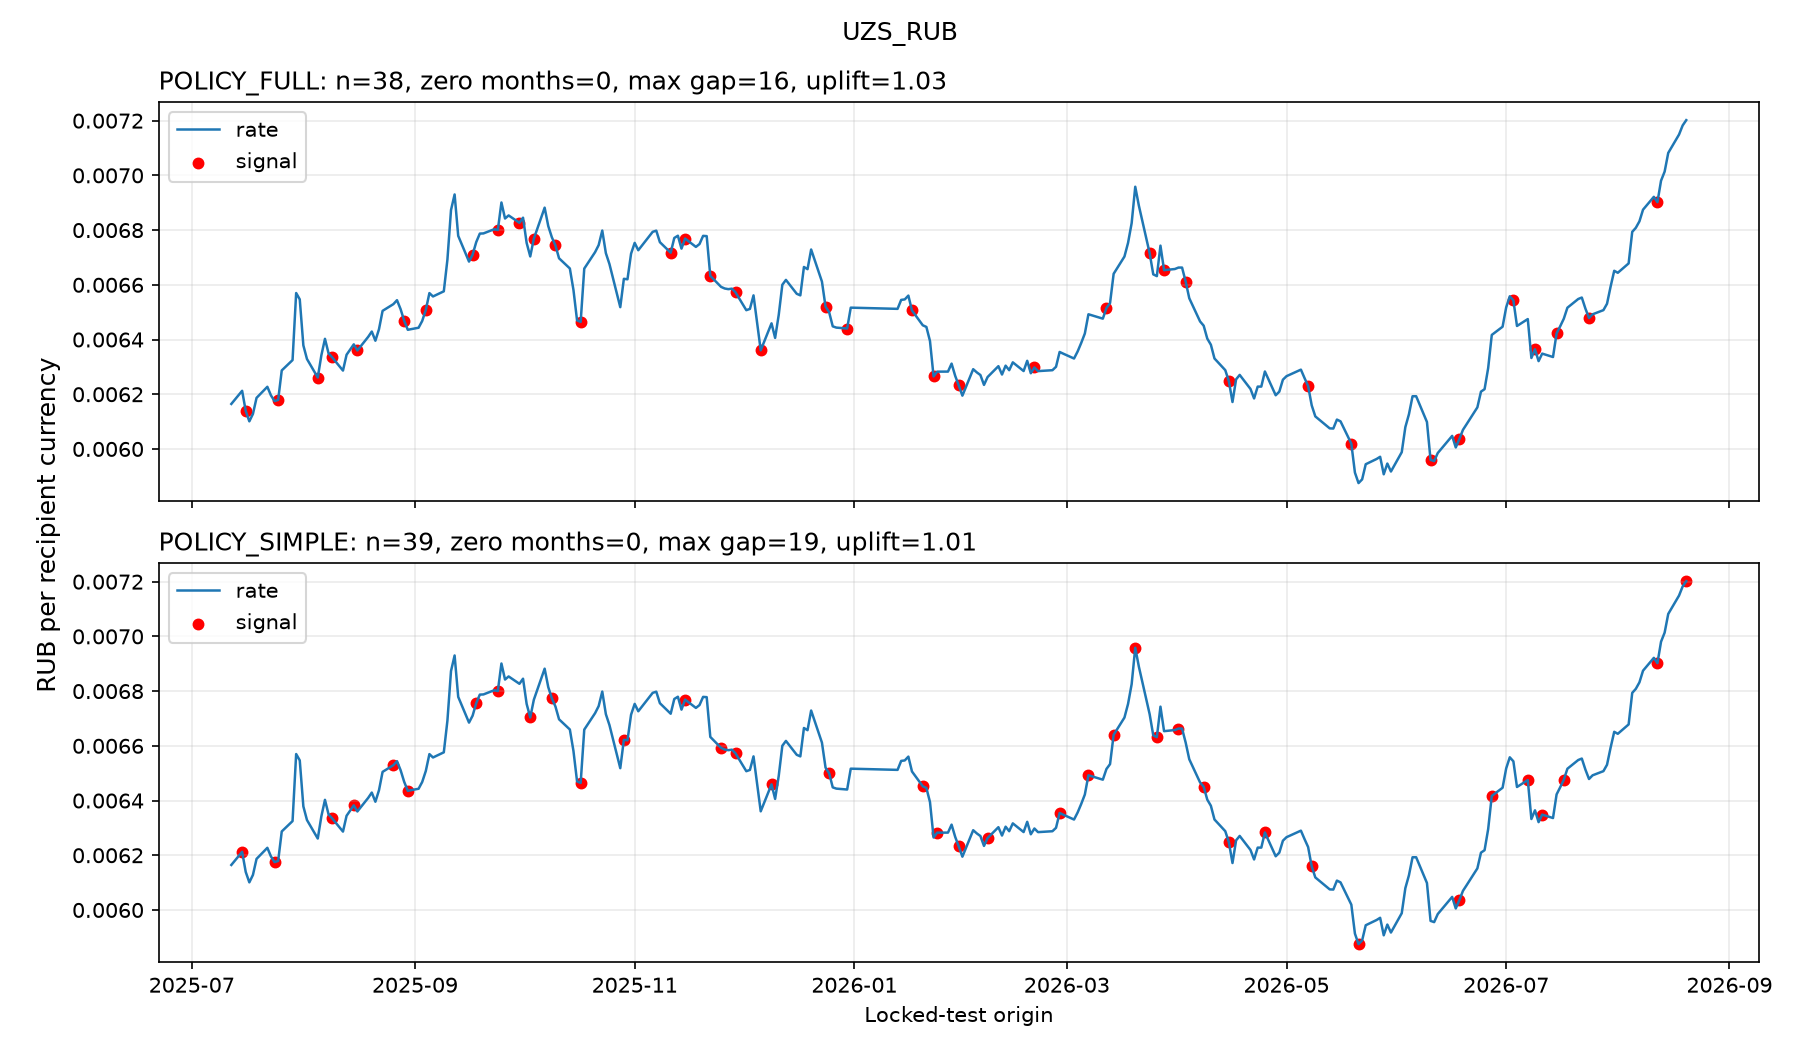

### UZS_RUB: отдельный POLICY_SIMPLE

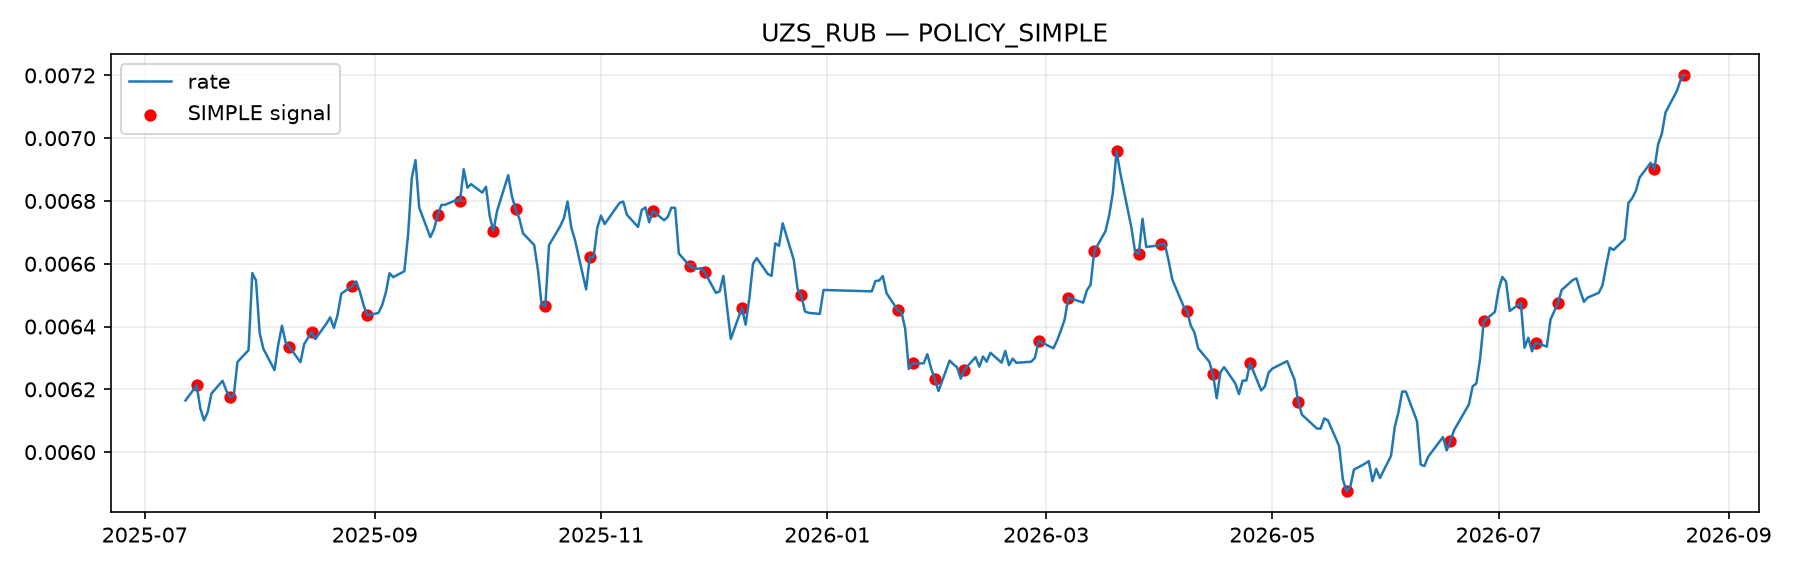

### AMD_RUB: score, adaptive threshold и сигналы

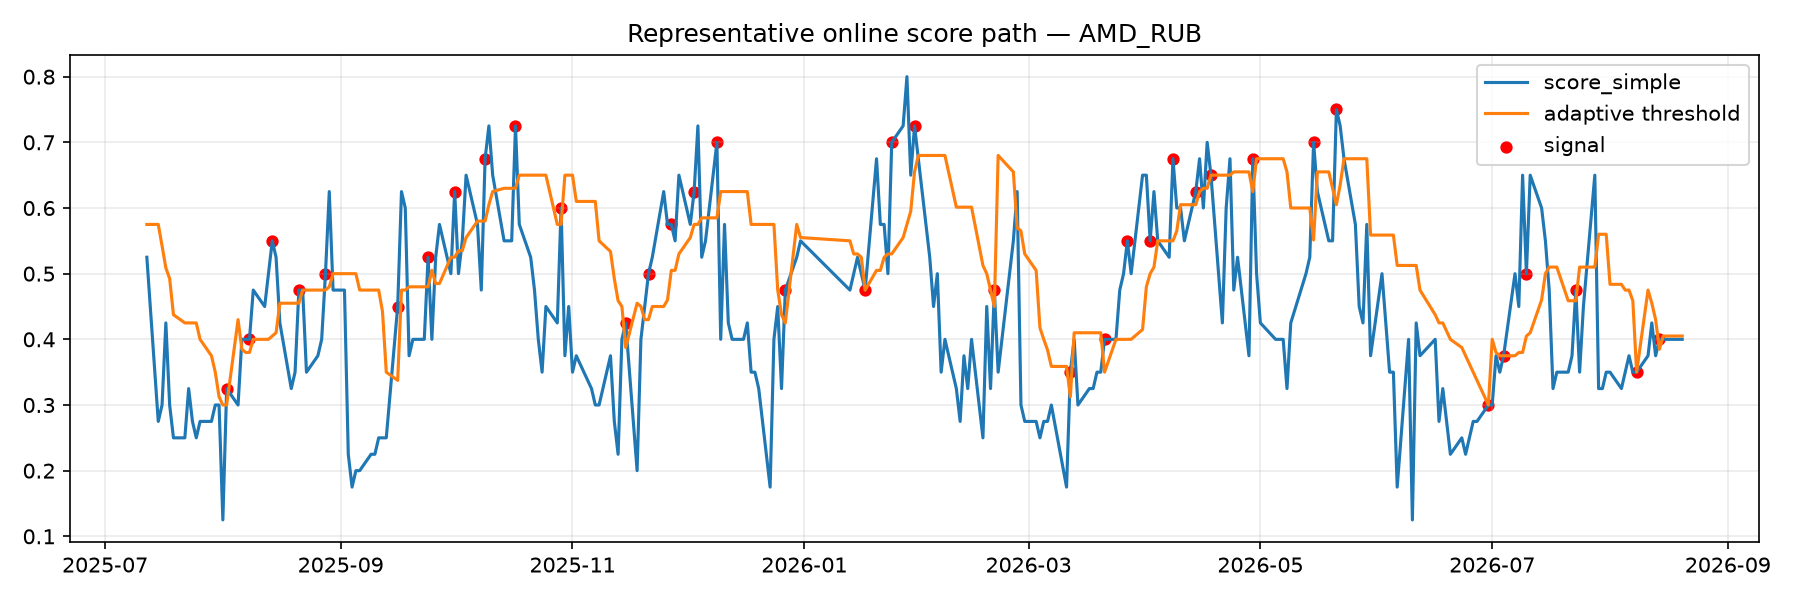

In [3]:
from IPython.display import Image, Markdown, display

FIGURE_DIR = ROOT / 'reports' / 'figures' / 'adaptive_ranking'
for corridor in sorted(result['test']['corridor'].unique()):
    display(Markdown(f'### {corridor}: FULL и SIMPLE'))
    display(Image(filename=str(FIGURE_DIR / f'{corridor}_full_vs_simple.png')))
    display(Markdown(f'### {corridor}: отдельный POLICY_SIMPLE'))
    display(Image(filename=str(FIGURE_DIR / f'{corridor}_simple.png')))

representative = sorted(result['test']['corridor'].unique())[0]
display(Markdown(f'### {representative}: score, adaptive threshold и сигналы'))
display(Image(filename=str(FIGURE_DIR / f'{representative}_representative_score.png')))

In [4]:
comparison = result['results'][result['results']['policy'].isin(['POLICY_FULL', 'POLICY_SIMPLE'])]
display(comparison)
status = 'PASS' if result['leakage']['passed'].all() else 'FAIL'
print(f'STAGE 13 LEAKAGE CHECK: {status}')
print(f'STAGE 13 — ADAPTIVE RANKING GOOD DAY: {status}')

,corridor,policy,n_signals,signal_frequency,mean_signals_per_month,median_signals_per_month,months_with_zero_signals,share_months_with_1plus,share_months_with_2plus,max_gap_quote_observations,mean_gap_quote_observations,hit_rate,random_hit_rate,uplift,mean_actual_regret_signal
0,AMD_RUB,POLICY_FULL,33,0.120000,2.357143,2.0,1,0.928571,0.785714,20,7.906250,0.090909,0.095152,0.955414,0.013233
1,AMD_RUB,POLICY_SIMPLE,37,0.134545,2.642857,3.0,1,0.928571,0.785714,27,7.083333,0.162162,0.094108,1.723148,0.011301
3,KGS_RUB,POLICY_FULL,35,0.127273,2.500000,3.0,0,1.000000,0.785714,17,7.882353,0.114286,0.095714,1.194030,0.012590
4,KGS_RUB,POLICY_SIMPLE,38,0.138182,2.714286,3.0,1,0.928571,0.928571,18,7.000000,0.157895,0.093474,1.689189,0.011171
6,KZT_RUB,POLICY_FULL,35,0.127273,2.500000,2.5,0,1.000000,0.785714,18,7.970588,0.142857,0.107029,1.334757,0.011813
7,KZT_RUB,POLICY_SIMPLE,39,0.141818,2.785714,2.5,0,1.000000,0.857143,19,7.078947,0.153846,0.104769,1.468429,0.011404
9,TJS_RUB,POLICY_FULL,34,0.123636,2.428571,2.0,1,0.928571,0.785714,18,7.666667,0.205882,0.112824,1.824818,0.010528
10,TJS_RUB,POLICY_SIMPLE,35,0.127273,2.500000,2.5,1,0.928571,0.785714,29,7.647059,0.142857,0.114914,1.243163,0.013029
12,UZS_RUB,POLICY_FULL,38,0.138182,2.714286,3.0,0,1.000000,0.857143,16,7.189189,0.078947,0.076842,1.027397,0.009959
13,UZS_RUB,POLICY_SIMPLE,39,0.141818,2.785714,2.5,0,1.000000,1.000000,19,7.184211,0.076923,0.076154,1.010101,0.011034


STAGE 13 LEAKAGE CHECK: PASS
STAGE 13 — ADAPTIVE RANKING GOOD DAY: PASS
